# 03 — Integration and differentiation

Composite Newton-Cotes (trapezoidal, Simpson) and finite differences
(forward, backward, central) are the basic building blocks of numerical
calculus. Plus Monte Carlo as a sanity check.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})

from numethods import (
    forward_diff, central_diff, richardson_extrapolation,
    trapezoid, simpson, monte_carlo,
)


## Finite-difference approximations to $\sin'(x)$

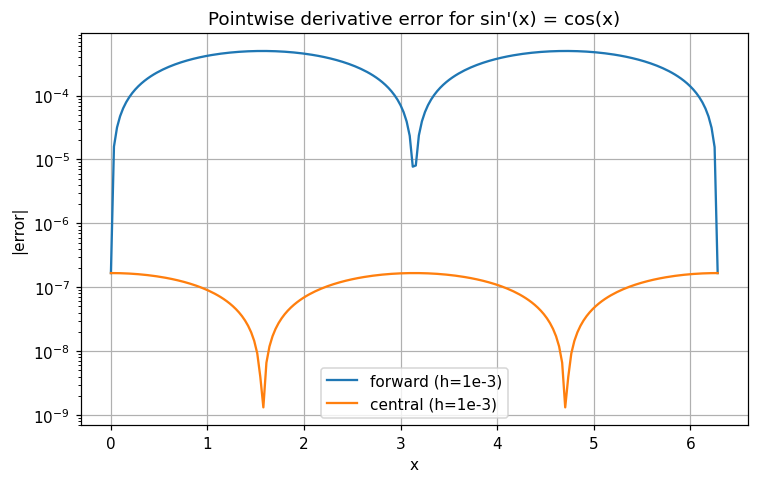

In [2]:
xs = np.linspace(0, 2*np.pi, 200)
truth = np.cos(xs)
f_err = np.abs(forward_diff(np.sin, xs, 1e-3) - truth)
c_err = np.abs(central_diff(np.sin, xs, 1e-3) - truth)
fig, ax = plt.subplots()
ax.plot(xs, f_err, label='forward (h=1e-3)')
ax.plot(xs, c_err, label='central (h=1e-3)')
ax.set_yscale('log'); ax.set_xlabel('x'); ax.set_ylabel('|error|')
ax.set_title("Pointwise derivative error for sin'(x) = cos(x)"); ax.legend()
fig.tight_layout(); plt.show()


## Approximating $\pi$ as twice the area of a half-disc

In [3]:
# integral_{-1}^{1} sqrt(1 - x^2) dx = pi/2
g = lambda x: np.sqrt(np.clip(1 - x**2, 0, None))
trap_pi = 2.0 * trapezoid(g, -1.0, 1.0, 4000).value
simp_pi = 2.0 * simpson(g, -1.0, 1.0, 4000).value
print(f'trapezoid pi ≈ {trap_pi:.6f}')
print(f'simpson   pi ≈ {simp_pi:.6f}')
print(f'true      pi = {np.pi:.6f}')


trapezoid pi ≈ 3.141580
simpson   pi ≈ 3.141588
true      pi = 3.141593


Endpoint singularities of the half-disc spoil the formal $\mathcal{O}(h^2)$ rate, but the value is still recognizable.

## Monte Carlo on a smooth integrand: $\int_0^1 e^{-x^2}\,dx$

In [4]:
rng = np.random.default_rng(42)

def integrand(x):
    return np.exp(-x**2)

res = monte_carlo(integrand, 0.0, 1.0, 200_000, rng=rng)
print(f'MC estimate: {res.value:.6f} ± {res.error_estimate:.2e}')
ref, ref_err = quad(integrand, 0.0, 1.0)
print(f'(scipy reference: {ref:.6f} ± {ref_err:.2e})')


MC estimate: 0.746858 ± 4.49e-04
(scipy reference: 0.746824 ± 8.29e-15)


This notebook demonstrates `numethods.differentiation` and `numethods.integration`.